In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import datetime as dt
import warnings
import statsmodels.api as sm     #Needed for Hodrick-Prescott (HP) Filter to separate time series into long-term trend vs cyclical component to determine 'Output Gap'
from scipy.sparse import SparseEfficiencyWarning
warnings.simplefilter('ignore', SparseEfficiencyWarning)
pd.options.display.float_format = '{:,.2f}'.format   #'${:,.2f}'.format to include $ signs

In [2]:
#Import historical daily S&P500 Master containing all individual stock data
#DAILY DATA BY COMPANY from 1970: 1,014,000 rows
df_sp500_master = pd.read_csv(r'F:\University of Waterloo\Data Science\Foundations of Data Science\Group Assignment\Data\SP500 Comprehensive\sp500_master_50years.csv')
df_sp500_master['Date'] = pd.to_datetime(df_sp500_master['Date'], utc=True).dt.tz_localize(None).dt.normalize()
#df_sp500_master

In [3]:
#Identify each company's Sector
df_company_sectors = df_sp500_master[['Ticker', 'Name', 'Sector']].drop_duplicates().set_index('Ticker').sort_index()
df_company_sectors

,Name,Sector
Ticker,,
AAPL,Apple Inc.,Technology
ABBV,AbbVie Inc.,Healthcare
ABT,Abbott Laboratories,Healthcare
ACN,Accenture plc,Technology
ADBE,Adobe Inc.,Technology
...,...,...
VZ,Verizon Communications Inc.,Communication Services
WM,"Waste Management, Inc.",Industrials
WMT,Walmart Inc.,Consumer Defensive


In [4]:
#Create Dictionary of tickers in each sector for later
dict_company_sectors = df_company_sectors.reset_index().groupby('Sector')['Ticker'].apply(list).to_dict()
#dict_company_sectors

In [5]:
#Number of companies in each Sector
df_company_sectors['Sector'].value_counts()

Sector
Healthcare                19
Technology                15
Financial Services        15
Industrials               11
Consumer Defensive        10
Consumer Cyclical          8
Communication Services     8
Basic Materials            4
Real Estate                3
Utilities                  3
Energy                     2
Name: count, dtype: int64

In [6]:
#Create DataFrame with all possible dates to ensure data is not lost
#20,505 rows
start_date = pd.to_datetime(df_sp500_master['Date'].min().year, format='%Y') #Replaces month + day with Jan 1
end_date = pd.to_datetime(df_sp500_master['Date'].max(), format='%Y-%m-%d')  #Keep last month + day
dates = pd.date_range(start=start_date, end=end_date, freq="D")              #Create all the dates
df_master = pd.DataFrame(dates,columns=['Date'])                             #Create DataFrame
df_master = df_master.set_index(['Date'])                                    #Set time as index
df_master.index = df_master.index.floor('D')                                 #Set time to 00:00:00 every day
#df_master

In [7]:
#Transform data so we have each company's historical close prices in individual columns.
#DAILY DATA from 1970: 14,155 rows
#NaNs in early days mean companies were not yet listed.
df_sp500_master = df_sp500_master.pivot(index='Date',columns='Ticker',values='Close')
#df_sp500_master

In [8]:
#Import historical daily S&P500 Index (GSPC)
#DAILY DATA from 1970: 14,155 rows
#The S&P500 is a float-adjusted, market-capitalization-weighted index maintained by S&P Dow Jones Indices
#It tracks the performance of 500 leading U.S. companies and covers approximately 80% of the total U.S. equity market value
#Since its inception in 1926, the index has provided a compound annual growth rate of approximately 9.8%, including dividends
df_GSPC = pd.read_csv(r'F:\University of Waterloo\Data Science\Foundations of Data Science\Group Assignment\Data\SP500 Comprehensive\sp500_index.csv',names=['DATE','CLOSE','HIGH','LOW','OPEN','VOLUME','TICKER'],header=0)
df_GSPC['DATE'] = pd.to_datetime(df_GSPC['DATE'], utc=True).dt.tz_localize(None).dt.normalize()
df_GSPC = df_GSPC.set_index(['DATE'])
#df_GSPC

In [9]:
#Import historical daily Consumer Price Index (CPIAUCSL)
#MONTHLY DATA from 1970: 673 rows
#A key measure of inflation tracked by the Federal Reserve Bank
#Measures the average change over time in the prices paid by urban consumers for a representative "market basket" of goods and services
#Seasonal Adjustment: adjusted to remove effects like weather, production cycles, and holidays, making it easier to see underlying price trends
df_CPI = pd.read_csv(r'F:\University of Waterloo\Data Science\Foundations of Data Science\Group Assignment\Data\SP500 Comprehensive\economic_CPI.csv')
df_CPI['DATE'] = pd.to_datetime(df_CPI['DATE'], utc=True).dt.tz_localize(None).dt.normalize()
df_CPI = df_CPI.set_index(['DATE'])
#df_CPI

In [10]:
#Import 10-Year Treasury Rate (DGS10)
#MONTHLY DATA from 1970: 673 rows
#Critical benchmark for long-term interest rates (incl. mortgage rates and corporate debt)
#Serves as barometer for market expectations regarding inflation and economic growth
#10-year T-notes are one of the safest investments due to low credit risk
df_DGS10 = pd.read_csv(r'F:\University of Waterloo\Data Science\Foundations of Data Science\Group Assignment\Data\SP500 Comprehensive\economic_DGS10.csv')
df_DGS10['DATE'] = pd.to_datetime(df_DGS10['DATE'], utc=True).dt.tz_localize(None).dt.normalize()
df_DGS10 = df_DGS10.set_index(['DATE'])
#df_DGS10

In [11]:
#Import Effective Federal Funds Rate (FEDFUNDS)
#MONTHLY DATA from 1970: 673 rows
#The interest rate at which depository institutions (banks and credit unions) lend reserve balances to other depository institutions overnight on an unsecured basis
#The primary tool used by the Federal Reserve to influence the U.S. economy
##Raising Rates: Used to combat high inflation by making borrowing more expensive, which cools economic activity
##Lowering Rates: Used to stimulate the economy or prevent rising unemployment by making borrowing cheaper
#Serves as a benchmark for consumer and business borrowing costs, including credit card rates and adjustable-rate mortgages
df_FEDFUNDS = pd.read_csv(r'F:\University of Waterloo\Data Science\Foundations of Data Science\Group Assignment\Data\SP500 Comprehensive\economic_FEDFUNDS.csv')
df_FEDFUNDS['DATE'] = pd.to_datetime(df_FEDFUNDS['DATE'], utc=True).dt.tz_localize(None).dt.normalize()
df_FEDFUNDS = df_FEDFUNDS.set_index(['DATE'])
#df_FEDFUNDS

In [12]:
#Import Gross Domestic Product (GDP)
#QUARTERLY DATA from 1970: 224 rows
#The standard economic measure for the total value of all finished goods and services produced within a country's borders during a specific period
#Growing GDP indicates a healthy, expanding economy; two consecutive quarters of negative growth often signal a recession
#The Federal Reserve uses GDP growth rates to decide whether to adjust interest rates to curb inflation or stimulate the economy
#High-growth periods generally lead to higher corporate profits and stronger stock market performance
df_GDP = pd.read_csv(r'F:\University of Waterloo\Data Science\Foundations of Data Science\Group Assignment\Data\SP500 Comprehensive\economic_GDP.csv')
df_GDP['DATE'] = pd.to_datetime(df_GDP['DATE'], utc=True).dt.tz_localize(None).dt.normalize()
df_GDP = df_GDP.set_index(['DATE'])
#df_GDP

In [13]:
#Import Civilian Unemployment Rate (UNRATE)
#MONTHLY DATA from 1970: 673 rows
#A key measure of labor market slack: represents the number of unemployed persons as a percentage of the civilian labor force
#The Federal Reserve Bank tracks this series as a "lagging indicator" to determine if the economy is overheating or if interest rate cuts are needed to support job growth
#Economists often use the "Sahm Rule" (which tracks the rise in the unemployment rate) as a signal for the start of a recession
df_UNRATE = pd.read_csv(r'F:\University of Waterloo\Data Science\Foundations of Data Science\Group Assignment\Data\SP500 Comprehensive\economic_UNRATE.csv')
df_UNRATE['DATE'] = pd.to_datetime(df_UNRATE['DATE'])
df_UNRATE = df_UNRATE.set_index(['DATE'])
#df_UNRATE

In [14]:
#Import CBOE Volatility Index (VIXCLS)
#DAILY DATA from 1990: 9,428 rows
#Fear Gauge: represents the market's expectation of 30-day volatility based on S&P 500 index option prices
#Inverse Relationship: typically the VIX moves in the opposite direction of the S&P 500 (when stock prices fall sharply, the VIX usually rises)
#Sentiment Thresholds:
##Below 20: generally indicates a "risk-on" environment with low stress and high investor confidence
##Above 30: indicates high fear and significant market turbulence
df_VIX = pd.read_csv(r'F:\University of Waterloo\Data Science\Foundations of Data Science\Group Assignment\Data\SP500 Comprehensive\economic_VIX.csv')
df_VIX['DATE'] = pd.to_datetime(df_VIX['DATE'], utc=True).dt.tz_localize(None).dt.normalize()
df_VIX = df_VIX.set_index(['DATE'])
#df_VIX

In [15]:
#Populate df_master's 20,505 rows
df_master = df_master.merge(df_GSPC['CLOSE'].rename('GSPC'), left_index=True, right_index=True, how='left') #S&P500 Index (GSPC) - DAILY DATA from 1970: 14,155 rows, 14,155 non-null
df_master = df_master.merge(df_VIX['VIXCLS'], left_index=True, right_index=True, how='left')                #CBOE Volatility Index (VIXCLS) - DAILY DATA from 1990: 9,428 rows, 9,127 non-null
df_master = df_master.merge(df_DGS10['DGS10'], left_index=True, right_index=True, how='left')               #10-Year Treasury Rate (DGS10) - DAILY DATA from 1970: 14,646 rows, 14,023 non-null
df_master = df_master.merge(df_CPI['CPIAUCSL'], left_index=True, right_index=True, how='left')              #Consumer Price Index (CPIAUCSL) - MONTHLY DATA from 1970: 673 rows, 672 non-null
df_master = df_master.merge(df_FEDFUNDS['FEDFUNDS'], left_index=True, right_index=True, how='left')         #Effective Federal Funds Rate (FEDFUNDS) - MONTHLY DATA from 1970: 673 rows, 673 non-null
df_master = df_master.merge(df_UNRATE['UNRATE'], left_index=True, right_index=True, how='left')             #Unemployment Rate (UNRATE) - MONTHLY DATA from 1970: 673 rows, 672 non-null
df_master = df_master.merge(df_GDP['GDP'], left_index=True, right_index=True, how='left')                   #Gross Domestic Product (GDP) - QUARTERLY DATA from 1970: 224 rows, 224 non-null
df_master = df_master.merge(df_sp500_master, left_index=True, right_index=True, how='left')                 #Individual stock tickers - DAILY DATA from 1970: 14,155 rows, various non-null (depending on time of listing of stock)
#df_master.to_csv('master.csv', index=True)
#df_master.info(verbose=True, show_counts=True)
#df_master.head()

In [16]:
#Add Recession indicator column using Sahm Rule (3-month moving average of Unemployment Rate rises by 0.5%+ above its 12-month low)
df_master.insert(6, 'UNRATE_ffilled', df_master['UNRATE'].ffill()) #Forward-fill monhtly UNRATE data to daily
df_master.insert(7, 'UNRATE_3moMA', df_master['UNRATE_ffilled'].rolling(window=63).mean()) #Add 3-month (63 trading days) moving average of unemployment
df_master.insert(8, 'UNRATE_12moLow', df_master['UNRATE_3moMA'].rolling(window=252).min()) #12-month (252 trading days) low of averages
df_master.insert(9, 'RECESSION', (df_master['UNRATE_3moMA'] - df_master['UNRATE_12moLow'] >= 0.5).astype(int)) #Add Recession indicator
df_master.insert(3, 'DGS10_ffilled', df_master['DGS10'].ffill()) #Forward-fill DGS10
df_master.insert(6, 'YieldSpread', df_master['DGS10_ffilled'] - df_master['FEDFUNDS']) #Add Yield Spread between long-term (DGS10: 10-Year Treasury Bond) and short-term (FEDFUNDS: Federal Funds Rate) interest rates to determine when the Yield Curve inversts (reliable predictor of upcoming recessions)
df_master.to_csv('master.csv', index=True)
#df_master.info(verbose=True, show_counts=True)
#df_master.head()

Indicator Definitions:
- GSPC (S&P 500 Index): the market - leading indicator for investor sentiment
- VIXCLS (VIX Volatility Index: The "Fear Gauge" - measures market stress/uncertainty
- DGS10 (10-Year Treasury Rate): Growth Expectations - benchmarks long-term borrowing costs
- CPIAUCSL (Consumer Price Index): Inflation - tracks the purchasing power of the dollar
- FEDFUNDS (The Fed Funds Rate): Monetary Policy - the interest rate set by the Federal Reserve
- UNRATE (Unemployment Rate): Labor Market - lagging indicator of economic health
- GDP (Gross Domestic Product): The "Scorecard" - total value of goods/services produced
- RECESSION: No (0) / Yes (1)

In [17]:
#Resample data to quarterly given GDP is quarterly
#Use actual values on the day of, instead of the mean for the quarter
df_quarterly = df_master.resample('QS').first()
df_quarterly = df_quarterly.iloc[:-1]               #Drop last row without GDP data
df_quarterly.insert(13, 'GDPlog', np.log(df_quarterly['GDP']))
df_quarterly.to_csv('quarterly.csv', index=True)
#df_quarterly.info(verbose=True, show_counts=True)
#df_quarterly.head()

In [18]:
#Apply Hodrick-Prescott (HP) Filter to separate time series into long-term trend vs cyclical component to determine 'Output Gap'
#cycle: Output Gap (short-term fluctuations / noise / business cycle movements vs long-term trend)
#trend: Potential GDP
#HP filter finds trend line as close to the actual data as possible that is as smooth as possible
#lamb (lambda): determines how much to penalize 'wiggles' in the trend line
#lamb = 1600 for quarterly data
#lamb = 14400 for monthly data
#lamb = 100 for annual data
cycle, trend = sm.tsa.filters.hpfilter(df_quarterly['GDPlog'].values, lamb=1600)
df_quarterly.insert(14, 'OutputGap', cycle)
df_quarterly.insert(15, 'PotentialGDP', trend)
diff = pd.Series(cycle).diff()
df_quarterly.insert(16, 'Expansion', ((cycle > 0) & (diff > 0)).astype(int).values)
df_quarterly.insert(17, 'Peak', ((cycle > 0) & (diff <= 0)).astype(int).values)
df_quarterly.insert(18, 'Contraction', ((cycle <= 0) & (diff <= 0)).astype(int).values)
df_quarterly.insert(19, 'Recovery', ((cycle <= 0) & (diff > 0)).astype(int).values)
df_quarterly.to_csv('quarterly.csv', index=True)
#df_quarterly.info(verbose=True, show_counts=True)
#df_quarterly.head()

OutputGap: describes current state of economy vs its full potential
- Calculated using GDPlog: represents percentage deviation of actual economy from its long-term sustainable trend
- Positive OutputGap (+0.0x): economy is 'overheating' (actual GDP higher than long-term trend) by x%
    - Interpretation: high demand, factories are running at max capacity, labor market is likely tight (low UNRATE)
    - Risk: typically leads to rising inflation (CPIAUCSL)
- Negative OutputGap (-0.0x): x% 'slack' in the economy (actual GDP below its potential)
    - Interpretation: economy is underperforming, factories are idle, and unemployment (UNRATE) is usually rising
    - Deep negative values are almost always associated with Recessions.
- Slope of OutputGap: indicates business cycle

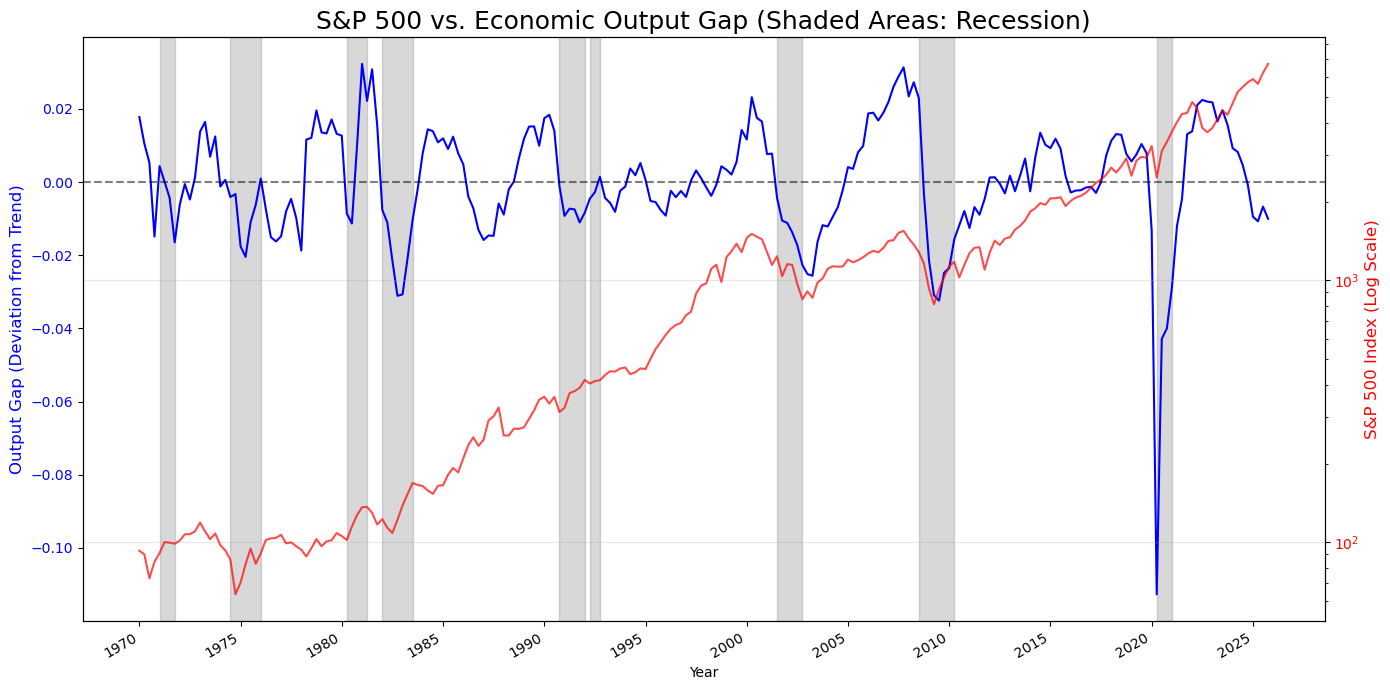

In [19]:
#Visualize relationship between the financial economy (stock market) and the real economy (output gap) using Dual-Axis Plot
#See if S&P500 (Leading Indicator) moves before Output Gap (Current State of economy)

#Plot Output Gap on Primary Y-Axis
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(df_quarterly.index, df_quarterly['OutputGap'], color='blue', linewidth=1.5, label='Output Gap')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Output Gap (Deviation from Trend)', color='blue', fontsize=12)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)            #Potential GDP baseline
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#Plot S&P500 on Secondary Y-Axis
ax2 = ax1.twinx()                                                   #Share X-axis & create new Y-axis
ax2.set_ylabel('S&P 500 Index (Log Scale)', color='red', fontsize=12)
ax2.plot(df_quarterly.index, df_quarterly['GSPC'], color='red', linewidth=1.5, alpha=0.7, label='S&P 500')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_yscale('log')                                               #Log scale (GSPC grows exponentially over time)

# Identify start and end dates for recessions
recession_periods = []
start_date = None

for date, row in df_quarterly.iterrows():
    if row['RECESSION'] == 1 and start_date is None:
        start_date = date
    elif row['RECESSION'] == 0 and start_date is not None:
        recession_periods.append((start_date, date))
        start_date = None

#Shade recession periods in graph
for start, end in recession_periods:
    ax1.axvspan(start, end, color='gray', alpha=0.3)

plt.title('S&P 500 vs. Economic Output Gap (Shaded Areas: Recession)', fontsize=18)
fig.autofmt_xdate()
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig('sp500_vs_outputgap.png')
plt.show();

- Leading Indicator: S&P500 prices in economoic dowturns & recoveries months before GDP reflects them.
- For example, 2008 financial crisis:
  - S&P500 started declining in late 2007, while Output Gap was still positive / economy still overheating for several months before finally turning negative)
  - S&P500 started increasing in 2009, while Output Gap was still very negative
- 2020 Shock Event (COVID-19): the drop in Output Gap was much more extreme (size & velocity) than during other economic cycles (output gap widened gradually). The S&P500 followed instantly, but also recovered at a record pace. During shock events the leading nature of the market is compressed into weeks / days rather than quarters.
- Negative Output Gap: economy is performing below potential
    - When S&P500 increasing while Output Gap still negative, investors are anticipating recovery before it actually shows up in GDP data.
- Positive Output Gap: economy is overheating
    - When S&P500 flattens / drops while Output Gap still positive, the Federal Reserve will raise interest rates to cool the economy (bad for stock 
- Current Trends: Output Gap (Blue) currently in negative territory; despite high stock prices, the real economy is performing slightly (~1%) below its calculated potential
- Recession Bars: economic context for S&P500 vs Output Gap
    - Recession Defined by Sahm Rule: 3-month moving average of Unemployment Rate rises by 0.5%+ above its 12-month low
    - Economic Troughs: Output Gaps' lowest points usually during recessions (inside gray shaded areas)
    - Stock Market Recoveries: S&P500 usually starts to recover before recessions (gray shaded areas) end, pricing in the eventual recovery

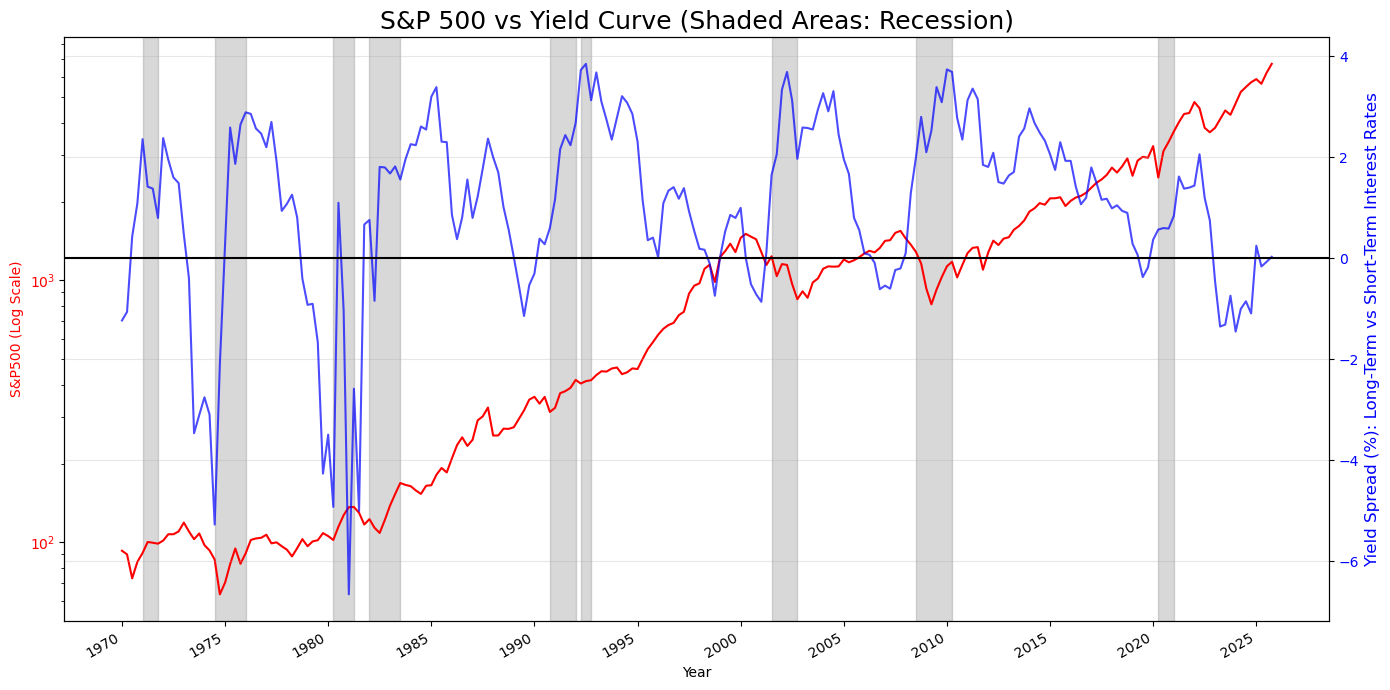

In [20]:
#Visualize Long-Term Interest Rate (DGS10: 10-Year Treasury Rate) vs Short-Term Interest Rate (FEDFUNDS: Federal Funds Rate)
#Yield Curve inversion occurs when short-term rates (FEDFUNDS: Federal Funds Rate) are higher than long-term rates (DGS10: 10-Year Treasury Rate)
#Yield Curve inversions are reliable predictors of upcoming recessions

#Plot S&P500 on Primary Y-Axis
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(df_quarterly.index, df_quarterly['GSPC'], color='red', linewidth=1.5, label='S&P500 Index (Log Scale)')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_yscale('log')       #Log scale (GSPC grows exponentially over time)
ax1.set_xlabel('Year')
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_ylabel('S&P500 (Log Scale)',color='red')

#Plot Yield SPread on Secondary Y-Axis
ax2 = ax1.twinx() #Share X-axis & create new Y-axis
ax2.plot(df_quarterly.index, df_quarterly['YieldSpread'], color='blue', linewidth=1.5, alpha=0.7, label='Yield Spread (%)')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0,color='black',linestyle='-')      #Add yield inversion line
ax2.set_ylabel('Yield Spread (%): Long-Term vs Short-Term Interest Rates', color='blue', fontsize=12)

#Shade recession periods in graph (recession_periods were identified in the graph above)
for start, end in recession_periods:
    ax1.axvspan(start, end, color='gray', alpha=0.3)

plt.title('S&P 500 vs Yield Curve (Shaded Areas: Recession)', fontsize=18)
fig.autofmt_xdate()
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig('S&P500 vs Yield Curve.png')
plt.show();

- S&P500 vs Yield Curve: a reliable predictor of an upcoming recession
    - Normal Yield Curve (Positive Spread): Investors demand higher returns for locking in their money for longer periods; this signals a healthy, growing economy
    - Inverted Yield Curve (Negative Spread): Investors are worried about the future, so they are willing to accept lower yields for longer-term bonds just to safely park their cash. It also indicates that the Federal Reserve has raised short-term interest rates aggressively to fight inflation.
- The Yield Curve inversion (lead indicator) happens when the Yield Spread goes negative
- The S&P500 follows the Yield Curve on a few month lag before recessions start
- The S&P500 often crashes after the Yield Curve starts to increase again, as the Fed panic cuts short-term interest rates as the economy begins to break

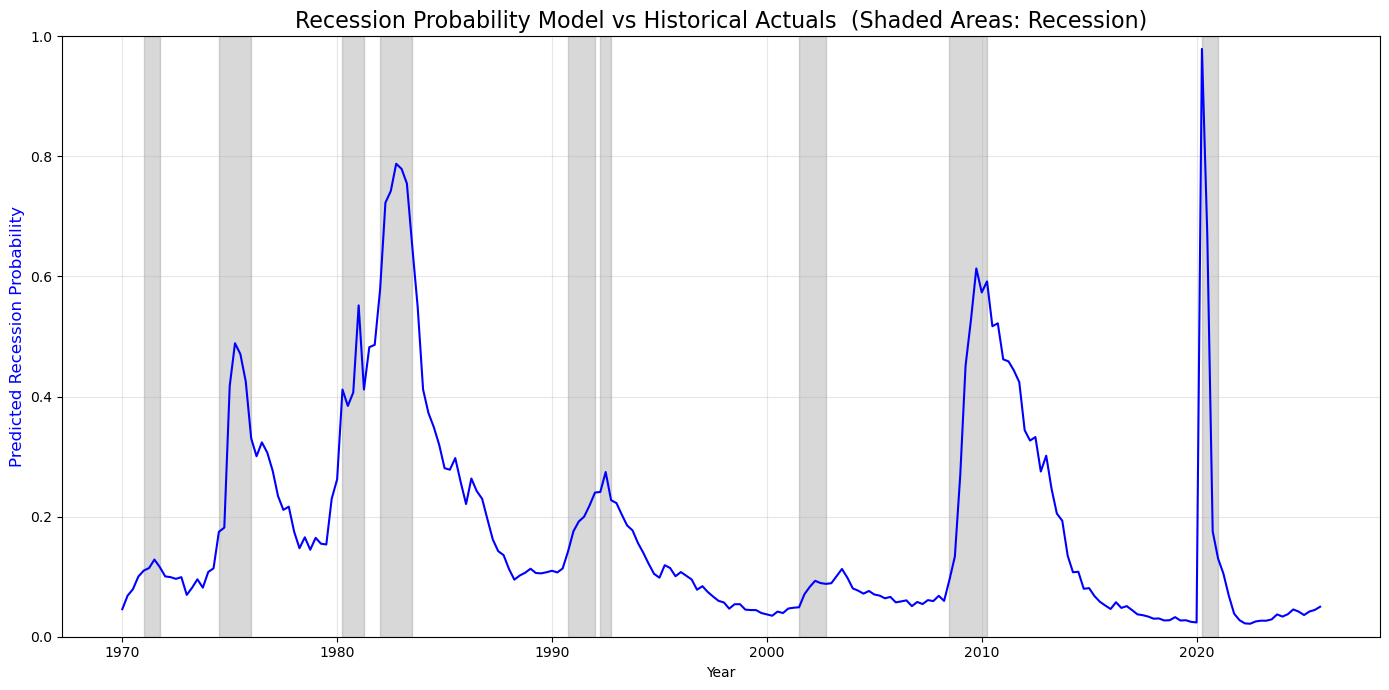

In [21]:
#Create Recession Probability Model using Logistic Regression:
#Dependent Variable: RECESSION (binary)
#Independent Variables (usually precede / coincide with economic downturns):
###YieldSpread: often goes negative / inverts before a recession
###Unemployment Rate (UNRATE): spikes during economic contractions
###Fed Funds Rate (FEDFUNDS): high rates can cool the economy too much, leading to recession

Y = df_quarterly['RECESSION']
X = df_quarterly[['YieldSpread', 'UNRATE', 'FEDFUNDS']]

#Standardize Independent Variables to prevent over-prioritizing variables with larger numbers
#No need to standardize the Dependent Variable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Run regression
model = LogisticRegression()
model.fit(X_scaled, Y)

#Calculate Probabilities
df_quarterly['Prob'] = model.predict_proba(X_scaled)[:, 1]

#Visualize
plt.figure(figsize=(14, 7))
plt.plot(df_quarterly.index, df_quarterly['Prob'], label='Model Recession Probability', color='blue', linewidth=1.5) #Plot the calculated model probability

#Shade recession periods in graph (recession periods were identified before)
for start, end in recession_periods:
    plt.axvspan(start, end, color='gray', alpha=0.3)

plt.title('Recession Probability Model vs Historical Actuals  (Shaded Areas: Recession)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Predicted Recession Probability', color='blue',fontsize=12)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();

In [22]:
#Regression Results
print("Regression Results:")
print(f"Intercept {model.intercept_[0]:.2f}")
print(pd.Series(model.coef_[0], index=X.columns))

Regression Results:
Intercept -1.87
YieldSpread   -0.08
UNRATE         1.20
FEDFUNDS       0.21
dtype: float64


The Recession Probability Model:\
-1.87 - 0.08 Yield Spread + 1.2 Unemployment Rate + 0.21 Fed Funds Rate

As seen from the graph above, the model is fairly good at predicting recessions.
- Unemployment Rate: most significant predictor; a sharp rise in the unemployment rate is the most reliable sign that a recession is fast approaching
- Yield Curve: leading indicator, as it often inverts (as seen above) months before a recession
- Fed Fund Rate: when the Federal Reserve raises rates to combat inflation during expansions / peaks, it often leads to contraction / recession

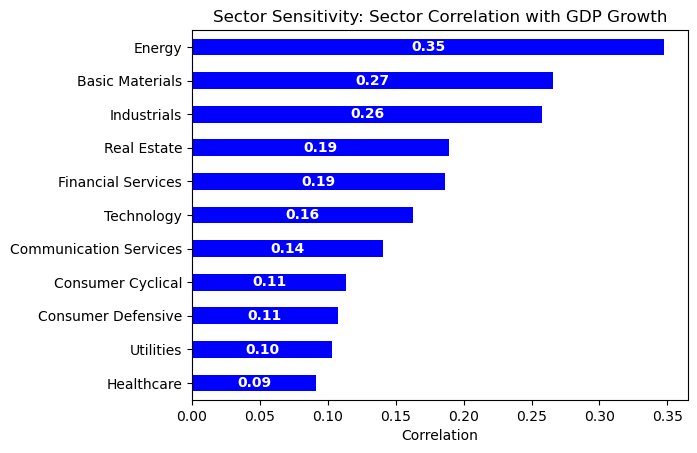

In [23]:
#Sector Sensitivity: sector correlation with GDP growth
df_quarterly.insert(14, 'GDPGrowth', df_quarterly['GDP'].pct_change()) #Calculate GDP Growth for correlation

results = {}
for name, tickers in dict_company_sectors.items():
    sector_return = df_quarterly[tickers].pct_change().mean(axis=1) # Average the returns of stocks in each sector
    results[name] = sector_return.corr(df_quarterly['GDPGrowth'])

ax = pd.Series(results).sort_values().plot(kind='barh', color='blue')
ax.bar_label(ax.containers[0],fmt='%.2f', label_type='center', color='white', fontweight='bold')
plt.title('Sector Sensitivity: Sector Correlation with GDP Growth')
plt.xlabel('Correlation')
plt.show();

Based on the Sector Sensitivity Analysis:
- Cyclical Industries: Energy, Basic Materials, and Industrials are most correlated with GDP Growth (35%, 27%, and 26% respectively)
- Defensive Industries: Heatlhcare and Utilities are least correlated with GDP Growth (9% and 10% respectively)

As an investment strategy, move investments into Energy, Basic Metals and Industrials during early recovery / economic expansion.